# Problem Set 5A

**Before starting:** download the `data` folder from the course webpage and
place it in the same directory as this notebook.

Unless a question says otherwise, do not write any Python `for` or `while`
loop over the elements of an array. Everything in this problem set can be done
with array operations, the `axis` argument, broadcasting and boolean masks.


## Question 1. Array attributes, reshaping and views

Create the array `a = np.arange(24)`.

1. Print its `size`, `ndim`, `dtype`, `itemsize` and `nbytes`. In one sentence,
   say how `nbytes` is related to `size` and `itemsize`.
2. Reshape `a` into `b` of shape `(4, 6)` and into `c` of shape `(2, 3, 4)`.
   Print the shape of each.
3. Set `b[0, 0] = -1` and then print `a[0]`. Explain in one sentence what this
   tells you about the array returned by `reshape`.
4. Now build `d = a.reshape(4, 6).copy()`, set `d[0, 0] = 99` and print `a[0]`
   again. Explain the difference from part 3.
5. Print the shape of `a.reshape(3, -1)` and say in one sentence what `-1`
   does.

`reshape` returns a _view_ whenever it can, that is, a second array object that
shares the same block of memory as the original. Writing through the view
therefore changes the original. Use `.copy()` when you want a genuinely
independent array. In `reshape`, at most one dimension may be given as `-1`,
and NumPy then works that dimension out from the total size.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

a = np.arange(24)

print("#1")
print("size : ",a.size," ndim : ",a.ndim," dtype : ",a.dtype," itemsize : ",a.itemsize," nbytes : ",a.nbytes)
print("nbytes = size * itemsize")
print('\n')

print("#2")
b = a.reshape((4,6))
print("Shape b : ",b.shape)
c = a.reshape((2,3,4))
print("Shape c : ",c.shape)
print('\n')

print("#3")
b[0,0] = -1
print("a[0] : ",a[0], " \nb is pointing to same location as a")
print('\n')

print("#4")
d=a.reshape(4,6).copy()
d[0,0]=99
print("a[0] : ",a[0], " \nd is not pointing to same location as a, it is a copy of a")
print('\n')

print("#5")
print("a.reshape(3,-1) : \n",a.reshape((3,-1)),"\n-1 basically tells it to fit the given array into the n-dimensions")


#1
size :  24  ndim :  1  dtype :  int64  itemsize :  8  nbytes :  192
nbytes = size * itemsize


#2
Shape b :  (4, 6)
Shape c :  (2, 3, 4)


#3
a[0] :  -1  
b is pointing to same location as a


#4
a[0] :  -1  
d is not pointing to same location as a, it is a copy of a


#5
a.reshape(3,-1) : 
 [[-1  1  2  3  4  5  6  7]
 [ 8  9 10 11 12 13 14 15]
 [16 17 18 19 20 21 22 23]] 
-1 basically tells it to fit the given array into the n-dimensions


## Question 2. Column statistics and standardisation by broadcasting

Load `data/data.txt` with `np.loadtxt`. Do **not** use `unpack=True`, so that
you get a single two-column array.

1. Print the shape of the array. Using the `axis` argument, compute the mean
   and the standard deviation of each column in one call each, and print them.
2. Standardise the data: subtract the column mean from each column and divide
   by the column standard deviation. Do this in a single expression using
   broadcasting, without any loop and without splitting the columns.
3. Check your answer with `np.allclose`: the standardised columns must have
   mean 0 and standard deviation 1.
4. Make one figure with two subplots: a scatter plot of column 1 against
   column 0 for the raw data, and the same for the standardised data. Give
   both subplots a title and axis labels.

The array has shape `(N, 2)` and `data.mean(axis=0)` has shape `(2,)`.
Comparing the shapes from the right, `2` matches `2` and the missing dimension
is treated as 1, so the two broadcast against each other and `data - mean`
subtracts the correct mean from each column. Note that `axis=0` collapses the
rows, which is what gives you a per-column result.


#1
shape :  (100, 2) 

Mean :  [64.37622952  1.71633598] 

Std :  [10.1727259   0.21189123] 

#3
True
True 

#4


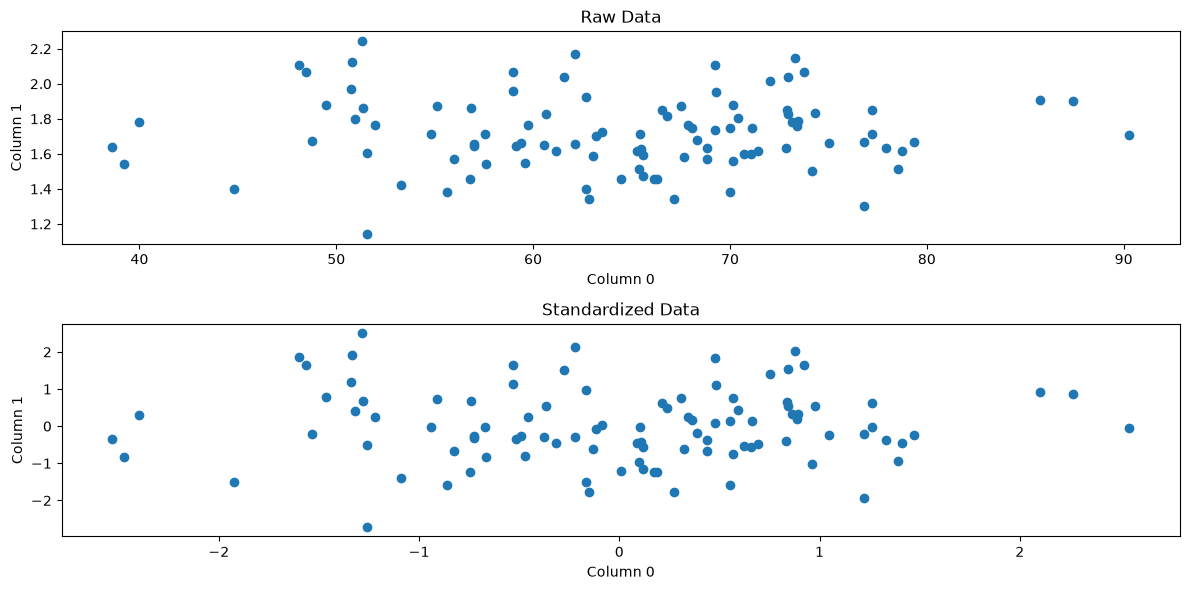

In [3]:

data=np.loadtxt("data/problem_set_4_data/data.txt")

print("#1")
print("shape : ",data.shape,'\n')
mean=np.mean(data,axis=0)
print("Mean : ",mean,'\n')
std=np.std(data,axis=0)
print("Std : ",std,'\n')

# print("#2")
data_std=(data-mean)/std

print("#3")
print(np.allclose(data_std.mean(axis=0), 0))
print(np.allclose(data_std.std(axis=0), 1),"\n")

print("#4")
plt.figure(figsize=(12,6))
plt.subplot(2,1,1)
plt.scatter(data[:,0],data[:,1])
plt.title("Raw Data")
plt.xlabel("Column 0")
plt.ylabel("Column 1")
plt.subplot(2,1,2)
plt.scatter(data_std[:,0],data_std[:,1])
plt.title("Standardized Data")
plt.xlabel("Column 0")
plt.ylabel("Column 1")

plt.tight_layout()
plt.show()

## Question 3. Broadcasting rules

For each of the following pairs of shapes, first work out **on paper** whether
the two arrays broadcast, and if they do, what the shape of the result is:

|     | shape A        | shape B     |
| --- | -------------- | ----------- |
| (a) | `(3, 4)`       | `(4,)`      |
| (b) | `(3, 4)`       | `(3,)`      |
| (c) | `(5, 1)`       | `(1, 6)`    |
| (d) | `(8, 1, 6, 1)` | `(7, 1, 5)` |
| (e) | `(2, 3)`       | `(3, 2)`    |

1. Write down your five predictions in a markdown cell.
2. Then write a loop **over the list of shape pairs** (this loop is allowed,
   it is not a loop over array elements) that calls `np.broadcast_shapes` inside
   a `try`/`except ValueError` and prints either the resulting shape or the word
   `incompatible`. Compare with your predictions.
3. Case (b) fails. Using `np.newaxis` (or `None`), turn the second array into a
   shape that _does_ broadcast against `(3, 4)`, and print the shape of the sum.
   Say in one sentence what the operation now means.

The rule is to line the two shapes up at their **rightmost** dimension and walk
leftwards. Two dimensions are compatible if they are equal or if one of them is
1; a missing dimension counts as 1. `a[:, np.newaxis]` inserts a new axis of
length 1, turning a shape `(3,)` into `(3, 1)`, which is how you get a column
vector to broadcast down the rows instead of across the columns.


#1

(a) Yes
(b) No
(c) Yes
(d) Yes
(e) No


In [4]:
print('#2')
shape_a = [(3, 4),(3, 4),(5, 1),(8, 1, 6, 1),(2, 3)]

shape_b = [(4,),(3,),(1, 6), (7, 1, 5), (3, 2)]

for i in range(5):
    try:
        result = np.broadcast_shapes(shape_a[i], shape_b[i])
        print(f"{shape_a[i]} + {shape_b[i]} -> {result}")
    except ValueError:
        print(f"{shape_a[i]} + {shape_b[i]} -> incompatible")

print('\n#3')
b = np.ones(shape_b[1])
b = b[:, np.newaxis]
result=np.ones(shape_a[1])+b
print(result.shape, " : Each element in a has been added to it's corresponding element in b")

#2
(3, 4) + (4,) -> (3, 4)
(3, 4) + (3,) -> incompatible
(5, 1) + (1, 6) -> (5, 6)
(8, 1, 6, 1) + (7, 1, 5) -> (8, 7, 6, 5)
(2, 3) + (3, 2) -> incompatible

#3
(3, 4)  : Each element in a has been added to it's corresponding element in b


## Question 4. A pairwise distance matrix without loops

Consider these five points in the plane:

```python
p = np.array([[0.0, 0.0], [1.0, 0.0], [1.0, 1.0], [0.0, 1.0], [0.5, 0.5]])
```

1. Using `np.newaxis` and broadcasting, build the array of coordinate
   differences and print its shape. It should be `(5, 5, 2)`.
2. From it, compute the matrix `D` of shape `(5, 5)` whose entry `D[i, j]` is
   the Euclidean distance between point `i` and point `j`. Do this without any
   loop. Print `D` rounded to three decimals.
3. Verify with `np.allclose` that `D` is symmetric and that its diagonal is
   zero. Verify also that you get the same `D` from `np.linalg.norm` with a
   suitable `axis` argument.
4. Display `D` with `plt.imshow`, add a colourbar, and label both axes with the
   point indices.
5. Find the indices of the two points that are farthest apart, using
   `np.argmax` together with `np.unravel_index`, and print them.

`p[:, np.newaxis, :]` has shape `(5, 1, 2)` and `p[np.newaxis, :, :]` has shape
`(1, 5, 2)`; their difference broadcasts to `(5, 5, 2)`, where entry `[i, j]` is
the vector from point `j` to point `i`. Squaring, summing over the last axis and
taking the square root then gives the distances. `np.argmax` returns a position
in the _flattened_ array, and `np.unravel_index` converts that back into a
`(row, column)` pair.


#1
Coordinate differences shape :  (5, 5, 2)

#2
[[0.    1.    1.414 1.    0.707]
 [1.    0.    1.    1.414 0.707]
 [1.414 1.    0.    1.    0.707]
 [1.    1.414 1.    0.    0.707]
 [0.707 0.707 0.707 0.707 0.   ]] 

#3
True
True
False

#4


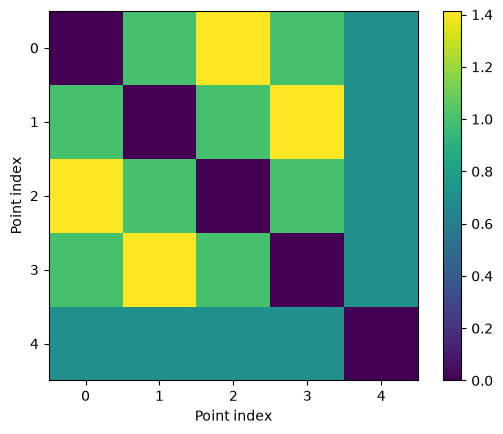


#5
np.argmax :  2
np.unravel_index :  (np.int64(0), np.int64(2))


In [5]:
p = np.array([[0.0,0.0],[1.0,0.0],[1.0,1.0],[0.0,1.0],[0.5,0.5]])

print("#1")
coordinate_differences= p[:,np.newaxis,:]-p[np.newaxis,:,:] 
print("Coordinate differences shape : ", coordinate_differences.shape)

print("\n#2")
D=np.round(np.sqrt(coordinate_differences[:,:,0]**2+coordinate_differences[:,:,1]**2),3)
print(D,"\n")

print("#3")
print(np.allclose(D,D.T))
print(np.allclose(np.diag(D),0))

D_norm = np.linalg.norm(coordinate_differences,axis=2)
print(np.allclose(D,D_norm))

print("\n#4")
plt.imshow(D)
plt.colorbar()
plt.xlabel("Point index")
plt.ylabel("Point index")
plt.xticks((range(5)))
plt.yticks((range(5)))
plt.show()

print("\n#5")
print("np.argmax : ",np.argmax(D))
print("np.unravel_index : ", np.unravel_index(np.argmax(D),D.shape))

## Question 5. A grid of points, contours and images

1. Build `t = np.linspace(-3, 3, 200)` and use `np.meshgrid` to obtain the two
   grid arrays `X` and `Y`. Print their shapes.
2. Evaluate

$$Z = e^{-\left((X-1)^2 + (Y-0.5)^2\right)} + 0.6\, e^{-2\left((X+1.5)^2 + (Y+1)^2\right)}$$

in a single vectorised expression.

3. Make one figure with two subplots. On the left, draw `Z` with
   `plt.contourf` and add a colourbar. On the right, draw the same `Z` with
   `plt.imshow`, passing `extent=[-3, 3, -3, 3]` and `origin='lower'` so that
   the axes carry the correct coordinates, and add a colourbar. Use a different
   colormap for each subplot.

4. Find the location `(x, y)` of the maximum of `Z` using `np.argmax` and
   `np.unravel_index`, print it, and mark it on the contour plot with a red
   cross.

`meshgrid` returns two 2-D arrays of the same shape, so any expression written
in terms of `X` and `Y` is evaluated at every grid point at once. Note the axis
convention: the first index of `Z` runs over `y` and the second over `x`, which
is why `imshow` needs `origin='lower'` to match the contour plot. The list of
available colormaps is in `plt.colormaps`.


#1
X shape :  (200, 200) Y shape :  (200, 200)

#3


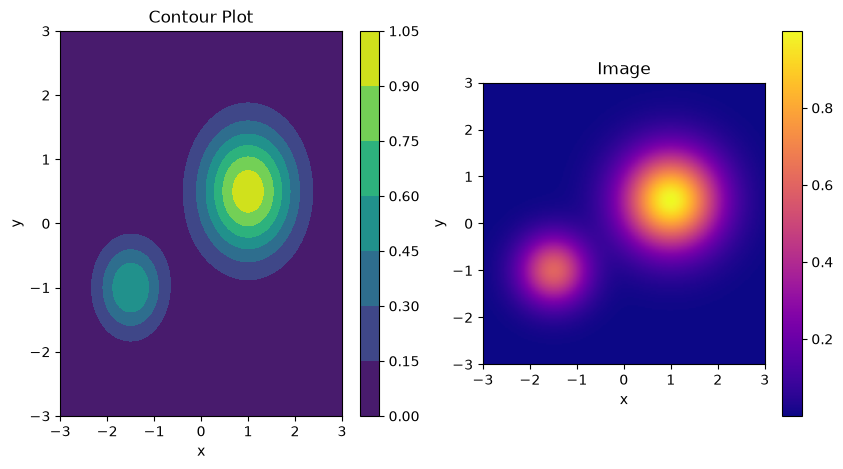


#4
Index of max value : ( 116 , 133 )


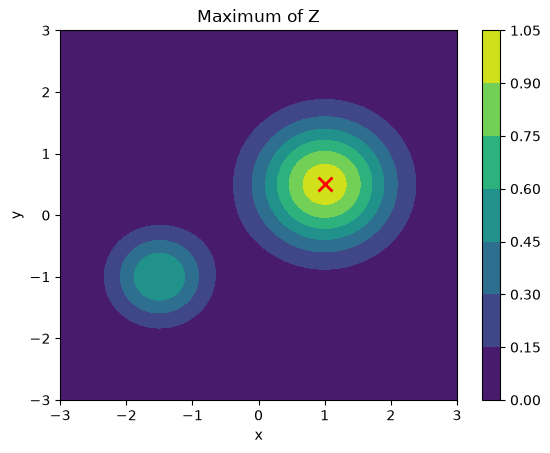

In [6]:
print("#1")
t= np.linspace(-3,3,200)
X,Y=np.meshgrid(t,t)
print("X shape : ",X.shape,"Y shape : ",Y.shape)

#2
Z = np.exp(-((X - 1)**2 + (Y - 0.5)**2)) + 0.6 * np.exp(-2 * ((X + 1.5)**2 + (Y + 1)**2))

print("\n#3")
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.contourf(X,Y,Z,cmap="viridis")
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Contour Plot")

plt.subplot(1,2,2)
plt.imshow(Z,extent=[-3,3,-3,3],origin="lower",cmap="plasma")
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Image")
plt.show()

print("\n#4")
max_index=np.argmax(Z)
pos_max_index_x,pos_max_index_y=np.unravel_index(max_index,Z.shape)
print("Index of max value : (",pos_max_index_x,",",pos_max_index_y,")")

x = X[pos_max_index_x, pos_max_index_y]
y = Y[pos_max_index_x, pos_max_index_y]

plt.figure()
plt.contourf(X, Y, Z, cmap="viridis")
plt.colorbar()

plt.plot(x, y, "rx", markersize=10, markeredgewidth=2)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Maximum of Z")

plt.show()

## Question 6. Boolean masks and an estimate of $\pi$

1. Set `np.random.seed(0)` and generate `n = 5000` points uniformly distributed
   in the square $[-1, 1) \times [-1, 1)$ using `np.random.random`. Scale and
   shift; do not use `np.random.uniform`.
2. Build a boolean mask that is `True` for the points lying inside the unit
   circle. Use it to form the two arrays `inside` and `outside`, and print
   their shapes.
3. Scatter the two sets in different colours on the same axes, draw the unit
   circle itself as a line, and use `plt.axis('equal')`.
4. The area of the circle is $\pi$ and the area of the square is 4, so the
   fraction of points inside estimates $\pi/4$. Print your estimate of $\pi$
   and its absolute error. Do this without any loop.

A comparison such as `r2 <= 1.0` gives a boolean array of the same shape.
Indexing with that array, `pts[mask]`, selects the rows where it is `True`, and
`~mask` is its negation. Because `True` counts as 1, `mask.sum()` is simply the
number of points inside.


#2
Inside circle shape :  (3925, 2)
Outside circle shape :  (1075, 2)

#3


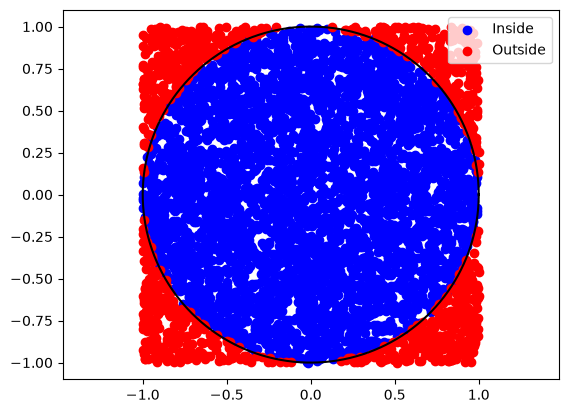


#4
Estimated pi: 3.14
Absolute error: 0.0015926535897929917


In [8]:
#1
np.random.seed(0)
pts = 2*np.random.random((5000,2))-1

print("#2")
r2 = pts[:, 0]**2 + pts[:, 1]**2
mask = r2 <= 1.0
inside_circle=pts[mask]
outside_circle=pts[~mask]
print("Inside circle shape : ",inside_circle.shape)
print("Outside circle shape : ",outside_circle.shape)

print("\n#3")
plt.scatter(inside_circle[:, 0], inside_circle[:, 1], color="blue", label="Inside")
plt.scatter(outside_circle[:, 0], outside_circle[:, 1], color="red", label="Outside")
theta = np.linspace(0, 2 * np.pi, 500)
plt.plot(np.cos(theta), np.sin(theta), color="black")
plt.axis("equal")
plt.legend()
plt.show()

print("\n#4")
pi_estimate = 4 * mask.sum() / 5000
absolute_error = abs(pi_estimate - np.pi)

print("Estimated pi:", pi_estimate)
print("Absolute error:", absolute_error)


## Question 7. Comparing batsmen with boolean masks

Load `data/sachin.txt`, `data/kohli.txt` and `data/rohit.txt` with
`np.loadtxt`. Each file holds one ODI score per line.

For each player, compute and print, using boolean masks and no loop over
innings:

1. the number of innings and the mean score,
2. the number of scores of 50 or more, and the number of 100 or more,
3. the conversion rate $P(X \geq 100 \mid X \geq 50)$,
4. the mean score in those innings where he passed 50.

Then draw a grouped bar chart comparing the three players on the counts of
50-plus and 100-plus scores, with the player names as tick labels and a legend.

Finally, write two or three sentences comparing the players. Say clearly which
comparisons are fair and which are affected by the different number of innings.

A mask such as `m50 = scores >= 50` can be used three ways: `m50.sum()` counts
the innings, `scores[m50]` selects those scores, and `(scores >= 100).sum() /
m50.sum()` is the conditional probability. For the grouped bars, plot the first
group at `x = np.arange(3) - 0.2` and the second at `x + 0.2` with
`width=0.4`, then set the tick labels with `plt.xticks`.


#1
Player : Number of innings : Mean score
Sachin :  452  :  40.76548672566372
Kohli :  290  :  48.9
Rohit :  265  :  42.14339622641509

#2
Player : Scores above 50 : Scores above 100
Sachin :  145  :  49
Kohli :  125  :  51
Rohit :  90  :  32

#3
Players : Conversion rate of players
Sachin :  0.33793103448275863
Kohli :  0.408
Rohit :  0.35555555555555557

#4
Player : Mean score in innings where score is above 50
Sachin :  90.13793103448276
Kohli :  91.472
Rohit :  93.03333333333333


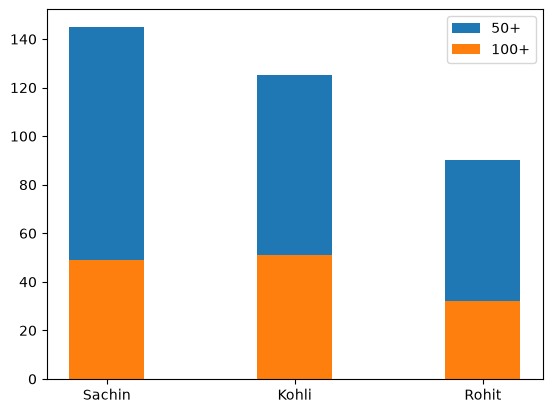


The raw number of 50+ and 100+ scores is affected by the different # number of innings played, so these counts are not completely fair # comparisons.
Conversion rate and mean score in 50+ innings are fairer # comparisons because they account for the opportunities each player had.



In [27]:
sachin=np.loadtxt("data/problem_set_4_data/sachin.txt")
kohli=np.loadtxt("data/problem_set_4_data/kohli.txt")
rohit=np.loadtxt("data/problem_set_4_data/rohit.txt")

print("#1")
print("Player : Number of innings : Mean score")
print("Sachin : ",sachin.size," : ",np.mean(sachin))
print("Kohli : ",kohli.size," : ",np.mean(kohli))
print("Rohit : ",rohit.size," : ",np.mean(rohit))

print("\n#2")
print("Player : Scores above 50 : Scores above 100")
s50=sachin>=50
s100=sachin>=100
k50=kohli>=50
k100=kohli>=100
r50=rohit>=50
r100=rohit>=100
print("Sachin : ",sachin[s50].size," : ",sachin[s100].size)
print("Kohli : ",kohli[k50].size," : ",kohli[k100].size)
print("Rohit : ",rohit[r50].size," : ",rohit[r100].size)

print("\n#3")
print("Players : Conversion rate of players")
print("Sachin : ",sachin[s100].size/sachin[s50].size)
print("Kohli : ",kohli[k100].size/kohli[k50].size)
print("Rohit : ",rohit[r100].size/rohit[r50].size)

print("\n#4")
print("Player : Mean score in innings where score is above 50")
print("Sachin : ",np.mean(sachin[s50]))
print("Kohli : ",np.mean(kohli[k50]))
print("Rohit : ",np.mean(rohit[r50]))

# Grouped bar chart
x = np.arange(3)
width = 0.4 
scores50 = [s50.sum(), k50.sum(), r50.sum()] 
scores100 = [s100.sum(), k100.sum(), r100.sum()] 
plt.bar(x, scores50, width=width, label="50+") 
plt.bar(x, scores100, width=width, label="100+") 
plt.xticks(np.arange(3), ["Sachin", "Kohli", "Rohit"]) 
plt.legend() 
plt.show()

print("""
The raw number of 50+ and 100+ scores is affected by the different # number of innings played, so these counts are not completely fair # comparisons.
Conversion rate and mean score in 50+ innings are fairer # comparisons because they account for the opportunities each player had.
""")

## Question 8. Splitting, stacking and concatenating

1. Build `a = np.arange(1, 13).reshape(3, 4)` and print it.
2. Use `np.hsplit` to split `a` into two blocks of shape `(3, 2)`, and
   `np.vsplit` to split it into three rows of shape `(1, 4)`. Print the shapes.
3. Rebuild `a` from each set of pieces with `np.concatenate`, choosing the
   right `axis`, and confirm with `np.array_equal` that you get the original
   back.
4. For `r = np.array([1, 2, 3])` and `s = np.array([4, 5, 6])`, print the shape
   of `np.stack((r, s))`, `np.stack((r, s), axis=1)`, `np.hstack((r, s))` and
   `np.vstack((r, s))`. In one or two sentences, explain the difference between
   `stack` and `concatenate`.
5. Using `np.concatenate` only, build the $6 \times 8$ block matrix

$$B = \begin{bmatrix} a & 2a \\ 3a & 4a \end{bmatrix}$$

print its shape, and display it with `plt.imshow` and a colourbar.

`concatenate` joins arrays along an axis that already exists, so the result has
the same number of dimensions as the inputs. `stack` creates a **new** axis, so
the result has one dimension more; `np.stack((r, s))` gives shape `(2, 3)`
while `np.stack((r, s), axis=1)` gives `(3, 2)`. For the block matrix, build the
two rows of blocks first and then join them.


#1
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]

#2
Shape of hsplit :  (3, 2) (3, 2)
Shape of vsplit :  (1, 4) (1, 4) (1, 4)

#3
Arrays h1 and h2 are equal :  True
Arrays v1, v2 and v3 are equal :  True

#4
Shape of np.stack((r,s)) :  (2, 3)
Shape of np.stack((r,s),axis=1) :  (3, 2)
Shape of np.hstack((r,s)) :  (6,)
Shape of np.vstack((r,s)) :  (2, 3)
stack creates a new axis, while concatenate joins arrays along an axis that already exists.

#5
Shape of B :  (6, 8)


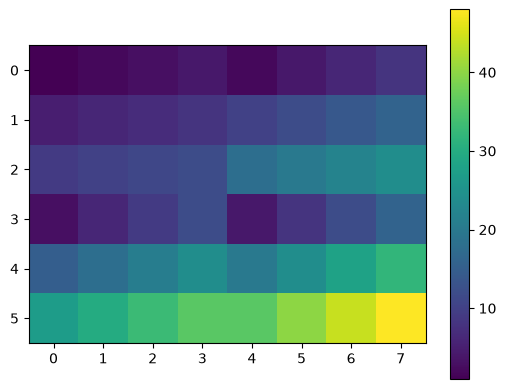

In [ ]:
print("#1")
a=np.arange(1,13).reshape(3,4)
print(a)

print("\n#2")
h1,h2=np.hsplit(a,2)
v1,v2,v3=np.vsplit(a,3)

print("Shape of hsplit : ",h1.shape,h2.shape)
print("Shape of vsplit : ",v1.shape,v2.shape,v3.shape)

print("\n#3")
print("Arrays h1 and h2 are equal : ",np.array_equal(np.concatenate((h1,h2),axis=1),a))
print("Arrays v1, v2 and v3 are equal : ",np.array_equal(np.concatenate((v1,v2,v3)),a))

print("\n#4")
r = np.array([1,2,3])
s = np.array([4,5,6])
print("Shape of np.stack((r,s)) : ",np.stack((r,s)).shape)
print("Shape of np.stack((r,s),axis=1) : ",np.stack((r,s),axis=1).shape)
print("Shape of np.hstack((r,s)) : ",np.hstack((r,s)).shape)
print("Shape of np.vstack((r,s)) : ",np.vstack((r,s)).shape)

print("stack creates a new axis, while concatenate joins arrays along " "an axis that already exists.") 

print("\n#5") 
top = np.concatenate((a, 2*a), axis=1) 
bottom = np.concatenate((3*a, 4*a), axis=1) 
B = np.concatenate((top, bottom), axis=0) 
print("Shape of B : ", B.shape) 
plt.imshow(B) 
plt.colorbar() 
plt.show()

## Question 9. Linear systems and eigenvalues

Consider

```python
A = np.array([[2.0, 1.0, -1.0], [-3.0, -1.0, 2.0], [-2.0, 1.0, 2.0]])
b = np.array([8.0, -11.0, -3.0])
```

1. Solve $Ax = b$ with `np.linalg.solve` and print `x`. Verify with
   `np.allclose` that `A @ x` equals `b`.
2. Print `np.linalg.det(A)`, compute `np.linalg.inv(A) @ b`, and confirm that
   it agrees with your `x`. In one sentence, say which of the two routes you
   would prefer in practice and why.
3. Now take the symmetric matrix

```python
S = np.array([[2.0, 1.0, 0.0], [1.0, 3.0, 1.0], [0.0, 1.0, 2.0]])
```

Use `np.linalg.eig` to get its eigenvalues `w` and eigenvectors `V`, and
print them. Remember that the eigenvectors are the **columns** of `V`. 4. For each eigenvalue, verify with `np.allclose` that $S v = \lambda v$. 5. Check that `V.T @ V` is the identity and that `V @ np.diag(w) @ V.T`
reproduces `S`. Say in one sentence why this works for a symmetric matrix. 6. Print `np.linalg.norm(S)` and confirm it equals the square root of the sum
of the squares of all the entries.

`np.linalg.eig` returns a tuple, so `w, V = np.linalg.eig(S)`. Column `k` is
`V[:, k]`, which pairs with the eigenvalue `w[k]`. You may use a `for` loop over
the three eigenvalues in part 4; that is a loop over three columns, not over
array elements.


In [49]:
A = np.array([[2.0, 1.0, -1.0],[-3.0, -1.0, 2.0],[-2.0, 1.0, 2.0]])
b = np.array([8.0, -11.0, -3.0])

print("#1")
x = np.linalg.solve(A, b)
print("x : ", x)
print("A @ x equals b : ", np.allclose(A @ x, b))

print("\n#2")
print("det(A) : ", np.linalg.det(A))
x_inv = np.linalg.inv(A) @ b
print("inv(A) @ b : ", x_inv)
print("inv(A) @ b equals x : ", np.allclose(x_inv, x))
print("In practice, np.linalg.solve is preferred because it is more efficient than explicitly computing the inverse.")

print("\n#3")
S = np.array([[2.0, 1.0, 0.0],[1.0, 3.0, 1.0],[0.0, 1.0, 2.0]])
w, V = np.linalg.eig(S)
print("Eigenvalues : ")
print(w)
print("Eigenvectors : ")
print(V)

print("\n#4")
for k in range(3):
    v = V[:, k]
    print("Eigenvalue : ", w[k])
    print("S @ v equals lambda @ v : ",np.allclose(S @ v, w[k] * v))

print("\n#5")
print("V.T @ V : ")
print(V.T @ V)
print("V.T @ V is identity :",np.allclose(V.T @ V, np.eye(3)))
print("V @ diag(w) @ V.T : ")
print(V @ np.diag(w) @ V.T)
print("Reproduces S :",np.allclose(V @ np.diag(w) @ V.T, S))
print("This works because a symmetric matrix has orthonormal eigenvectors, allowing it to be decomposed as S = V @ diag(w) @ V.T.")

print("\n#6")
norm_S = np.linalg.norm(S)

sum_of_squares = np.sum(S ** 2)
sqrt_sum_of_squares = np.sqrt(sum_of_squares)

print("np.linalg.norm(S) : ", norm_S)
print("sqrt(sum of squares) : ", sqrt_sum_of_squares)

print("They are equal : ",np.allclose(norm_S, sqrt_sum_of_squares))


#1
x :  [ 2.  3. -1.]
A @ x equals b :  True

#2
det(A) :  -0.9999999999999996
inv(A) @ b :  [ 2.  3. -1.]
inv(A) @ b equals x :  True
In practice, np.linalg.solve is preferred because it is more efficient than explicitly computing the inverse.

#3
Eigenvalues : 
[4. 2. 1.]
Eigenvectors : 
[[-4.08248290e-01  7.07106781e-01  5.77350269e-01]
 [-8.16496581e-01  2.17862563e-16 -5.77350269e-01]
 [-4.08248290e-01 -7.07106781e-01  5.77350269e-01]]

#4
Eigenvalue :  4.000000000000001
S @ v equals lambda @ v :  True
Eigenvalue :  2.000000000000001
S @ v equals lambda @ v :  True
Eigenvalue :  0.9999999999999993
S @ v equals lambda @ v :  True

#5
V.T @ V : 
[[1.00000000e+00 3.70798423e-16 1.49937486e-16]
 [3.70798423e-16 1.00000000e+00 1.39213053e-16]
 [1.49937486e-16 1.39213053e-16 1.00000000e+00]]
V.T @ V is identity : True
V @ diag(w) @ V.T : 
[[ 2.00000000e+00  1.00000000e+00 -6.47919214e-16]
 [ 1.00000000e+00  3.00000000e+00  1.00000000e+00]
 [-6.47919214e-16  1.00000000e+00  2.00000000e+0

## Question 10. A least squares fit and the value of $g$

`data/pendulum.txt` holds the length $L$ of a simple pendulum in the first
column and its time period $T$ in the second.

1. Load the two columns with `np.loadtxt` and `unpack=True`, and compute
   `tsq = T**2`.
2. Theory says $T = 2\pi\sqrt{L/g}$, so $T^2 = (4\pi^2/g)\, L$, a straight
   line through the origin. Fit the more general line $T^2 = mL + c$ by
   building the design matrix

$$
A = \begin{bmatrix} L_1 & 1 \\ L_2 & 1 \\ \vdots & \vdots \\ L_N & 1
\end{bmatrix}
$$

and calling `np.linalg.lstsq(A, tsq, rcond=None)`. Print $m$ and $c$. 3. Plot the data as points and the fitted line on the same axes, with axis
labels and a legend. 4. From the slope, estimate $g = 4\pi^2/m$. Print your estimate and its
percentage difference from $9.81\ \mathrm{m/s^2}$. 5. Compute the residuals $T^2 - Ap$, print the norm of the residual vector and
the coefficient of determination $R^2 = 1 - \mathrm{SS_{res}}/
   \mathrm{SS_{tot}}$, and plot the residuals against $L$ in a second figure.
In two sentences, say whether the straight line is a good model here and what
the intercept $c$ tells you.

`np.array([L, np.ones_like(L)])` has shape `(2, N)`, so transpose it to get the
`(N, 2)` design matrix. `lstsq` returns a tuple whose **first** element is the
solution vector; `rcond=None` silences a future-version warning.
$\mathrm{SS_{tot}}$ is the sum of squares of `tsq - tsq.mean()`.


#2
m :  [4.14148447 0.07358041] 
c :  0.07358041497643945
#3


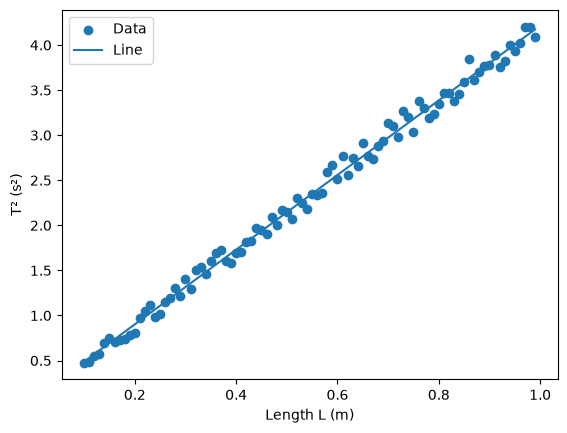

#4
Estimated g = 9.532431649795756 m/s²
Percentage difference :  2.829442917474462 %
#5
Residual norm :  0.7975560345300042
R² = 0.9939316003682754


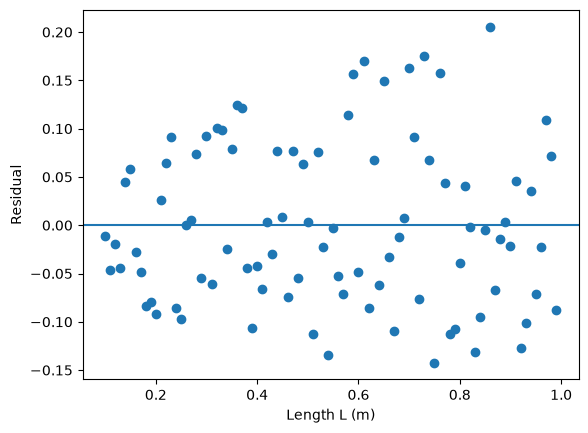

In [ ]:
#1
L,T=np.loadtxt("data/problem_set_4_data/pendulum.txt", unpack=True)
tsq=T**2

print("#2")
A=np.array([L,np.ones_like(L)]).T
p=np.linalg.lstsq(A,tsq,rcond=None)[0]
m,c=p
print("m : ",p,"\nc : ",c)

print("#3")
tsq_fit = A @ p

plt.scatter(L, tsq, label="Data")
plt.plot(L, tsq_fit, label="Line")
plt.xlabel("Length L (m)")
plt.ylabel("T² (s²)")
plt.legend()
plt.show()

print("#4")
g = 4 * np.pi**2 / m
percentage_difference = abs(g - 9.81) / 9.81 * 100

print("Estimated g : ", g, "m/s²")
print("Percentage difference : ", percentage_difference, "%")

print("#5")
residuals = tsq - A @ p

print("Residual norm : ", np.linalg.norm(residuals))

SS_res = np.sum(residuals**2)
SS_tot = np.sum((tsq - tsq.mean())**2)

R2 = 1 - SS_res / SS_tot

print("R² =", R2)

# Residual plot
plt.scatter(L, residuals)
plt.axhline(0)
plt.xlabel("Length L (m)")
plt.ylabel("Residual")
plt.show()